# Research: BC-ResNet Compression Limits for Embedded Systems

**Author**: Jerônimo Augusto Soares

**Objective**: Identify the lower limit of parameters and MACs for the BC-ResNet architecture 
before accuracy degradation in distinguishing $N$ voice commands.

## Libraries and Dependencies

In [1]:
import os
import re
import time
from glob import glob
import sys

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchinfo import summary

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter, NullFormatter
from matplotlib.lines import Line2D

from sklearn.metrics import (
    balanced_accuracy_score,
    recall_score,
    average_precision_score,
    top_k_accuracy_score,
)

sys.path.append("..")

from src.utils import set_seed
from src.dataset import (
    download_gsc_dataset,
    create_gsc_dataframes,
    SpeechCommandsDataset,
    PreprocessingDataLoader,
)
from src.transforms import AudioPreprocessor
from src.bcresnet import BCResNets

## Global Configurations

In [2]:
MODEL_DIR = "../models/"
RESULTS_DIR = "../results/"
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures/")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables/")

DATA_DIR = "../data"
VER = 2

# fmt: off
VOCAB_CONFIGS = {
    1: ["marvin"], 
    2: ["yes", "no"],
    4: ["up", "down", "left", "right"],
    10: ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"],
    24: [
        "yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go",
        "backward", "forward", "follow", "learn",
        "zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"
    ]
}
# fmt: on

SEED_TEST = 314  # Seed for reproducibility in tests, based on PI

## Data Loading

In [3]:
base_dir = download_gsc_dataset(
    destination_dir=DATA_DIR, version=VER, keep_archive=True
)
noise_dir = os.path.join(base_dir, "_background_noise_")

# Create DataFrames only once
df_train, df_valid, df_test, df_noise = create_gsc_dataframes(base_dir)

Dataset already fully extracted at ../data\speech_commands_v0.02. Skipping download.
Scanning dataset at: ../data\speech_commands_v0.02 ...


## Model Loading

In [4]:
list_models = glob(os.path.join(MODEL_DIR, "bcresnet_*.pt"))
list_models.sort()

models = {}

print(f"Found {len(list_models)} models. Starting loading process...")

for model_path in list_models:
    filename = os.path.basename(model_path)

    # Parameter extraction via Regex
    match = re.search(r"bcresnet_v2_N(\d+)_tau([\d\.]+)_hl(\d+)_seed(\d+)", filename)

    if match:
        n = int(match.group(1))
        tau = float(match.group(2))
        hop_length = int(match.group(3))
        seed = int(match.group(4))
    else:
        print(f"Skipped (invalid format): {filename}")
        continue

    # Construct the expected history filename based on the model name
    history_filename = filename.replace("bcresnet_", "history_")
    history_path = os.path.join(MODEL_DIR, history_filename)

    if not os.path.exists(history_path):
        print(f"Warning: History not found for {filename}")
        continue

    # Instantiate the model
    model = BCResNets(int(tau * 8), num_classes=n + 2)

    # SAFE LOADING:
    # map_location='cpu' ensures we don't overload the GPU memory just by loading weights.
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.eval()  # Set to evaluation mode

    history = torch.load(history_path, map_location="cpu", weights_only=False)

    # Nested dictionary structuring
    if n not in models:
        models[n] = {}
    if tau not in models[n]:
        models[n][tau] = {}
    if hop_length not in models[n][tau]:
        models[n][tau][hop_length] = {}

    models[n][tau][hop_length][seed] = {"model": model, "history": history}

print(f"Loading completed.")

Found 200 models. Starting loading process...
Loading completed.


## Running Inference

### def run_inference

In [5]:
def run_inference(model, test_loader, device):
    """
    Runs inference on the test set and returns raw data for analysis.

    Args:
        model (nn.Module): The trained model.
        test_loader (DataLoader): DataLoader containing test data.
        device (str): Device to run evaluation on ('cpu' or 'cuda').

    Returns:
        tuple: (y_true, y_pred, logits)
            - y_true (np.array): Ground truth labels.
            - y_pred (np.array): Predicted classes (argmax).
            - logits (np.array): Raw model output [N_samples, N_classes].
    """
    model.eval()

    y_true = []
    y_pred = []
    logits_list = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            _, preds = torch.max(output, 1)

            logits_list.extend(output.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(target.cpu().numpy())

    return (
        np.array(y_true, dtype=np.int8),
        np.array(y_pred, dtype=np.int8),
        np.array(logits_list, dtype=np.float32),
    )

### Running Inference on Test Set

In [6]:
BATCH_SIZE = 100
SILENCE_LIMIT_TEST = (
    len(df_test) // 5
)  # Maximum number of silence samples in the test set

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {device}")

start_time = time.time()
results_list = []

for n in models:
    set_seed(SEED_TEST)
    target_classes = VOCAB_CONFIGS[n]

    test_ds = SpeechCommandsDataset(
        df_test,
        target_classes,
        base_dir,
        mode="test",
        cache_ram=True,
        limit_unknown=len(df_test),  # Includes all available "unknown" samples
        limit_silence=SILENCE_LIMIT_TEST,
        random_state=SEED_TEST,
    )

    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    for tau in models[n]:
        for hop_length in models[n][tau]:
            preprocess_eval = AudioPreprocessor(
                device=device,
                noise_dir=noise_dir,
                specaug=False,
                hop_length=hop_length,
            )

            test_iter = PreprocessingDataLoader(
                test_loader, preprocess_eval, is_train=False
            )

            for seed in models[n][tau][hop_length]:
                set_seed(SEED_TEST)
                test_ds.set_random_state(SEED_TEST)

                print(f"Inference: N={n}, TAU={tau}, HL={hop_length}, SEED={seed}")

                model = models[n][tau][hop_length][seed]["model"].to(device)
                y_true, y_pred, logits = run_inference(model, test_iter, device)

                # Move model back to CPU to free VRAM
                model.cpu()

                results_list.append(
                    {
                        "N": n,
                        "TAU": tau,
                        "HOP_LENGTH": hop_length,
                        "SEED": seed,
                        "y_true": y_true,
                        "y_pred": y_pred,
                        "logits": logits,
                    }
                )

df_results = pd.DataFrame(results_list)
df_results.to_pickle(os.path.join(RESULTS_DIR, "inference_results.pkl"))

end_time = time.time()
elapsed_time = end_time - start_time
print(
    "Inference completed. Total time: %02d:%02d:%02d"
    % (elapsed_time // 3600, (elapsed_time % 3600) // 60, elapsed_time % 60)
)

Running inference on: cuda
Random seed set to: 314
[TEST] Loading 11005 speech samples into RAM...


Load Speech: 100%|██████████| 11005/11005 [01:29<00:00, 122.30it/s]


[TEST] Loading background noise...
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=160, SEED=0
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=160, SEED=24
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=160, SEED=37
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=160, SEED=42
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=160, SEED=73
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=320, SEED=0
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=320, SEED=24
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=320, SEED=37
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=320, SEED=42
Random seed set to: 314
Inference: N=10, TAU=0.125, HL=320, SEED=73
Random seed set to: 314
Inference: N=10, TAU=0.25, HL=160, SEED=0
Random seed set to: 314
Inference: N=10, TAU=0.25, HL=160, SEED=24
Random seed set to: 314
Inference: N=10, TAU=0.25, HL=160, SEED=37
Random seed set to: 314
Inference: N=10, TAU=0.25, HL=160, SEED=42
Random seed set to: 

Load Speech: 100%|██████████| 11005/11005 [00:19<00:00, 554.50it/s]


[TEST] Loading background noise...
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=160, SEED=0
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=160, SEED=24
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=160, SEED=37
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=160, SEED=42
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=160, SEED=73
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=320, SEED=0
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=320, SEED=24
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=320, SEED=37
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=320, SEED=42
Random seed set to: 314
Inference: N=1, TAU=0.125, HL=320, SEED=73
Random seed set to: 314
Inference: N=1, TAU=0.25, HL=160, SEED=0
Random seed set to: 314
Inference: N=1, TAU=0.25, HL=160, SEED=24
Random seed set to: 314
Inference: N=1, TAU=0.25, HL=160, SEED=37
Random seed set to: 314
Inference: N=1, TAU=0.25, HL=160, SEED=42
Random seed set to: 314
Inference:

...

[TEST] Loading background noise...
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=160, SEED=0
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=160, SEED=24
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=160, SEED=37
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=160, SEED=42
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=160, SEED=73
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=320, SEED=0
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=320, SEED=24
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=320, SEED=37
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=320, SEED=42
Random seed set to: 314
Inference: N=24, TAU=0.125, HL=320, SEED=73
Random seed set to: 314
Inference: N=24, TAU=0.25, HL=160, SEED=0
Random seed set to: 314
Inference: N=24, TAU=0.25, HL=160, SEED=24
Random seed set to: 314
Inference: N=24, TAU=0.25, HL=160, SEED=37
Random seed set to: 314
Inference: N=24, TAU=0.25, HL=160, SEED=42
Random seed set to: 

Load Speech: 100%|██████████| 11005/11005 [00:19<00:00, 568.94it/s]


[TEST] Loading background noise...
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=160, SEED=0
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=160, SEED=24
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=160, SEED=37
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=160, SEED=42
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=160, SEED=73
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=320, SEED=0
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=320, SEED=24
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=320, SEED=37
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=320, SEED=42
Random seed set to: 314
Inference: N=2, TAU=0.125, HL=320, SEED=73
Random seed set to: 314
Inference: N=2, TAU=0.25, HL=160, SEED=0
Random seed set to: 314
Inference: N=2, TAU=0.25, HL=160, SEED=24
Random seed set to: 314
Inference: N=2, TAU=0.25, HL=160, SEED=37
Random seed set to: 314
Inference: N=2, TAU=0.25, HL=160, SEED=42
Random seed set to: 314
Inference:

Load Speech: 100%|██████████| 11005/11005 [00:19<00:00, 570.77it/s]


[TEST] Loading background noise...
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=160, SEED=0
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=160, SEED=24
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=160, SEED=37
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=160, SEED=42
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=160, SEED=73
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=320, SEED=0
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=320, SEED=24
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=320, SEED=37
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=320, SEED=42
Random seed set to: 314
Inference: N=4, TAU=0.125, HL=320, SEED=73
Random seed set to: 314
Inference: N=4, TAU=0.25, HL=160, SEED=0
Random seed set to: 314
Inference: N=4, TAU=0.25, HL=160, SEED=24
Random seed set to: 314
Inference: N=4, TAU=0.25, HL=160, SEED=37
Random seed set to: 314
Inference: N=4, TAU=0.25, HL=160, SEED=42
Random seed set to: 314
Inference:

### Loading Saved Inference Results

In [7]:
file_path = os.path.join(RESULTS_DIR, "inference_results.pkl")

if os.path.exists(file_path):
    print(f"Loading {file_path}...")

    df_results = pd.read_pickle(file_path)

    # Verification of the loaded data
    print("\n--- First rows ---")
    display(df_results.head())

else:
    print(f"Error: File '{file_path}' not found.")

Loading ../results/inference_results.pkl...

--- First rows ---


,N,TAU,HOP_LENGTH,SEED,y_true,y_pred,logits
0,10,0.125,160,0,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 3, 11, 5, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,...","[[-0.53226376, 1.1116066, 0.57698685, 0.674746..."
1,10,0.125,160,24,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[2, 2, 5, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, ...","[[0.6688981, 1.9467643, 2.2100935, 1.1825463, ..."
2,10,0.125,160,37,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[3, 9, 4, 3, 3, 3, 3, 3, 3, 5, 2, 5, 5, 3, 5, ...","[[-5.215044, 0.49864465, 1.812324, 2.1796134, ..."
3,10,0.125,160,42,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[2, 9, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, ...","[[-13.268637, 4.215803, 7.0543294, 5.8107033, ..."
4,10,0.125,160,73,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[2, 2, 11, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,...","[[-7.953905, 4.286725, 7.954352, 6.864627, -4...."


## Metrics

### Helper Functions

In [8]:
def calculate_metrics(row):
    """
    Calculates detailed performance metrics from raw inference results.
    Class structure assumed: 0: Silence, 1: Unknown, 2+: Target Commands.
    """
    y_true = row["y_true"]
    y_pred = row["y_pred"]
    logits = row["logits"]
    n_targets = row["N"]

    num_classes = n_targets + 2
    all_labels = list(range(num_classes))

    # from_numpy avoids unnecessary copying
    logits_tensor = torch.from_numpy(logits).float()

    with torch.no_grad():
        probs = F.softmax(logits_tensor, dim=1).numpy()

    # Confidence score (max probability) of the predicted class
    max_probs = np.max(probs, axis=1)

    # --- Global Metrics ---
    # Balanced Accuracy: Crucial due to class imbalance (Unknown >> Targets)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    top_1_acc = top_k_accuracy_score(y_true, probs, k=1, labels=all_labels)

    top_3_acc = (
        top_k_accuracy_score(y_true, probs, k=3, labels=all_labels)
        if num_classes > 3
        else np.nan
    )

    # --- Group Analysis (Rejection vs Targets) ---
    recalls = recall_score(
        y_true, y_pred, average=None, labels=all_labels, zero_division=0
    )

    # Rejection Recall (Specificity): Average of Silence (0) and Unknown (1)
    rejection_recall = recalls[0:2].mean()

    # Target Recall (Sensitivity): Average of target command classes (index 2 onwards)
    target_recall = recalls[2:].mean()

    # --- Macro Metrics ---
    try:
        y_true_onehot = np.eye(num_classes)[y_true]
        macro_auc_pr = average_precision_score(y_true_onehot, probs, average="macro")
    except Exception:
        macro_auc_pr = np.nan

    # --- Calibration Analysis ---
    correct_mask = y_true == y_pred

    # Mean confidence for correct vs wrong predictions
    conf_correct = np.mean(max_probs[correct_mask]) if np.any(correct_mask) else np.nan
    conf_wrong = np.mean(max_probs[~correct_mask]) if np.any(~correct_mask) else np.nan

    return {
        "balanced_acc": balanced_acc,
        "top_1_acc": top_1_acc,
        "top_3_acc": top_3_acc,
        "rejection_recall": rejection_recall,
        "target_recall": target_recall,
        "macro_auc_pr": macro_auc_pr,
        "conf_correct": conf_correct,
        "conf_wrong": conf_wrong,
    }


def get_input_shape(hop_length, sample_rate=16000, duration_sec=1, n_mels=40):
    """
    Calculates the input spectrogram shape based on hop_length.
    Simulates torchaudio.transforms.MelSpectrogram behavior (center=True).
    """
    audio_len_samples = sample_rate * duration_sec
    n_frames = (audio_len_samples // hop_length) + 1

    # Shape format: [Batch, Channel, Freq, Time]
    return (1, 1, n_mels, n_frames)

### Performance Metrics Calculation

In [9]:
print("Calculating detailed metrics for each model...")
metrics_dicts = []

# Iterates over the results DataFrame to compute metrics per trial
for i, row in df_results.iterrows():
    metrics = calculate_metrics(row)

    metrics_dicts.append(
        {
            "N": row["N"],
            "TAU": row["TAU"],
            "HOP_LENGTH": row["HOP_LENGTH"],
            "SEED": row["SEED"],
            **metrics,
        }
    )

df_metrics = pd.DataFrame(metrics_dicts)

print("Aggregating results (Mean and Standard Deviation)...")

# Define columns for grouping and analysis
group_cols = ["N", "TAU", "HOP_LENGTH"]
metric_cols = [c for c in df_metrics.columns if c not in group_cols + ["SEED"]]

# Group by hyperparameters and calculate statistics across seeds
grouped = df_metrics.groupby(group_cols)[metric_cols].agg(["mean", "std"])

# Flatten MultiIndex columns (e.g., balanced_acc_mean, balanced_acc_std)
grouped.columns = ["_".join(col).strip() for col in grouped.columns.values]
df_aggregated = grouped.reset_index()

Calculating detailed metrics for each model...
Aggregating results (Mean and Standard Deviation)...


### Complexity Calculation (Params and MACs)

In [10]:
complexity_data = []
processed_configs = set()

# Iterates over the models dictionary loaded in memory
for n in models:
    for tau in models[n]:
        for hop_length in models[n][tau]:

            # Seed does not affect Params or MACs, so we use a unique config ID
            config_id = (n, tau, hop_length)

            if config_id in processed_configs:
                continue

            # Use the first available seed for this configuration
            first_seed = list(models[n][tau][hop_length].keys())[0]
            model_instance = models[n][tau][hop_length][first_seed]["model"]

            # Generate dummy input with the correct spectrogram dimensions
            input_shape = get_input_shape(hop_length)
            dummy_input = torch.zeros(input_shape)

            # Extract MACs and Parameters using torchinfo summary
            stats = summary(model_instance, input_data=dummy_input, verbose=0)

            complexity_data.append(
                {
                    "N": n,
                    "TAU": tau,
                    "HOP_LENGTH": hop_length,
                    "Params": stats.total_params,
                    "MACs": stats.total_mult_adds,
                }
            )

            processed_configs.add(config_id)

### Merge

In [11]:
df_complexity = pd.DataFrame(complexity_data)

# Merges performance metrics with complexity data
df_metrics_agg = df_aggregated.merge(
    df_complexity, on=["N", "TAU", "HOP_LENGTH"], how="left"
)

# Reorder columns for better readability
lead_cols = ["N", "TAU", "HOP_LENGTH", "Params", "MACs"]
rest_cols = [c for c in df_metrics_agg.columns if c not in lead_cols]
df_metrics_agg = df_metrics_agg[lead_cols + rest_cols]

print("Processing completed.")

df_metrics_agg.to_csv(os.path.join(TABLES_DIR, "aggregated_metrics.csv"), index=False)

df_metrics_agg

Processing completed.


,N,TAU,HOP_LENGTH,Params,MACs,balanced_acc_mean,balanced_acc_std,top_1_acc_mean,top_1_acc_std,top_3_acc_mean,...,rejection_recall_mean,rejection_recall_std,target_recall_mean,target_recall_std,macro_auc_pr_mean,macro_auc_pr_std,conf_correct_mean,conf_correct_std,conf_wrong_mean,conf_wrong_std
0,1,0.125,160,544,167329,0.965522,0.005806,0.980585,0.004313,NaN,...,0.988283,0.002384,0.920000,0.018702,0.958889,0.007314,0.973295,0.002418,0.731465,0.017035
1,1,0.125,320,544,84629,0.969257,0.006107,0.980509,0.003243,NaN,...,0.988244,0.002401,0.931282,0.020059,0.965933,0.006757,0.973770,0.003716,0.740215,0.012237
2,1,0.250,160,1408,399884,0.980654,0.004371,0.984174,0.003549,NaN,...,0.990467,0.002395,0.961026,0.010634,0.981087,0.005265,0.984844,0.003119,0.748881,0.014094
3,1,0.250,320,1408,202234,0.979399,0.003975,0.985098,0.002050,NaN,...,0.991150,0.001255,0.955897,0.011806,0.983403,0.004009,0.984260,0.003046,0.735594,0.022010
4,1,0.500,160,3365,947225,0.981998,0.003486,0.987945,0.002002,NaN,...,0.992997,0.001208,0.960000,0.009864,0.987377,0.002164,0.989155,0.002086,0.762965,0.034811
5,1,0.500,320,3365,478925,0.981740,0.005507,0.987430,0.001618,NaN,...,0.992610,0.001108,0.960000,0.017162,0.988088,0.002529,0.988839,0.002198,0.740346,0.025981
6,1,1.000,160,8935,2484287,0.985910,0.000980,0.987718,0.003825,NaN,...,0.992711,0.002380,0.972308,0.005847,0.990233,0.001826,0.989523,0.002365,0.759344,0.025751
7,1,1.000,320,8935,1255687,0.985603,0.001862,0.988611,0.004780,NaN,...,0.993276,0.003018,0.970256,0.006686,0.990774,0.001909,0.988634,0.005222,0.731884,0.026485
8,2,0.125,160,549,167334,0.832064,0.200530,0.821036,0.121716,0.995835,...,0.857206,0.142212,0.806922,0.259145,0.786760,0.195881,0.819691,0.173519,0.657054,0.069695
9,2,0.125,320,549,84634,0.876018,0.147508,0.834681,0.177488,0.998516,...,0.876510,0.139899,0.875525,0.155511,0.848496,0.149519,0.830511,0.186023,0.666778,0.119284


## Plots and Visualizations

### Pareto Frontiers

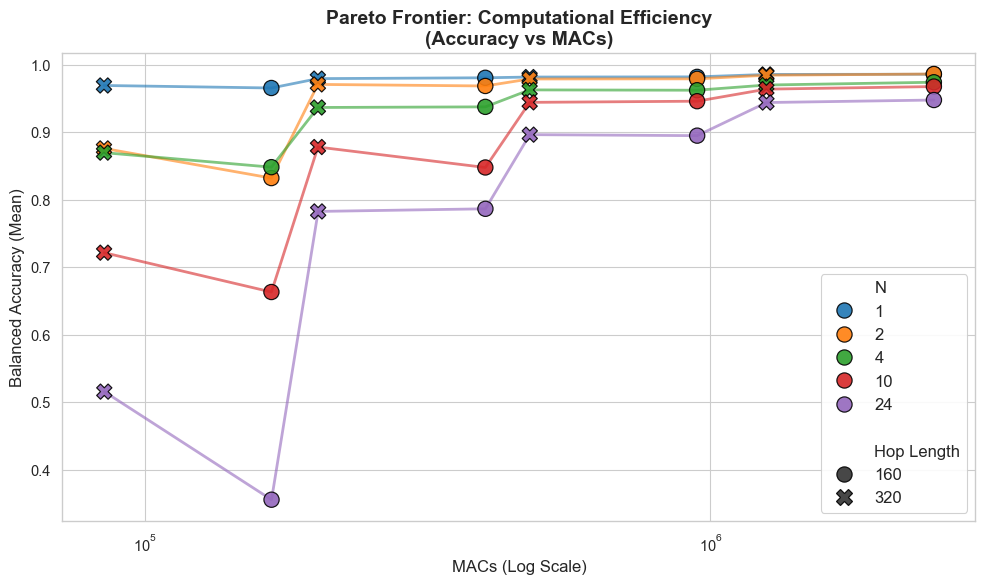

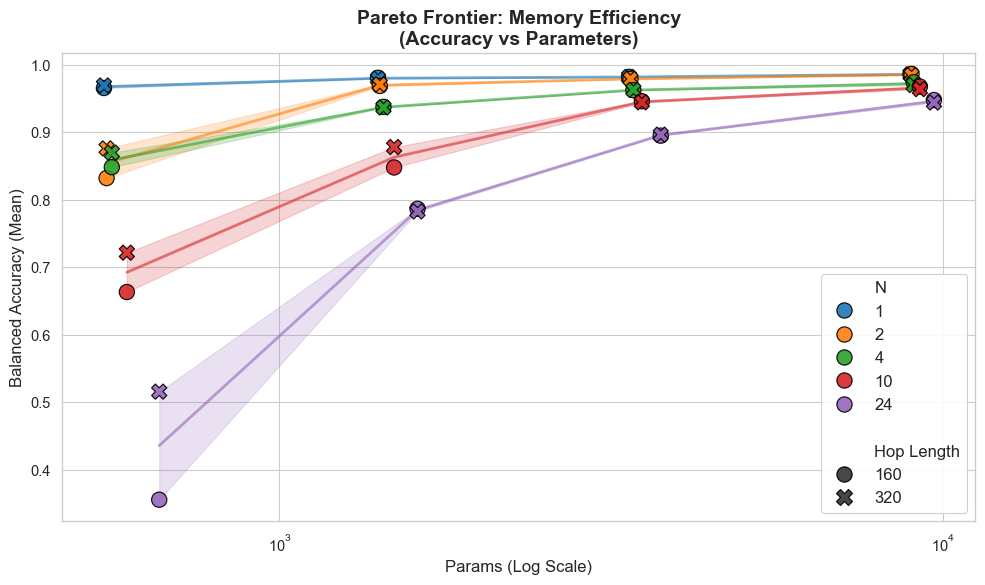

In [12]:
# Aesthetic configuration
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


def plot_pareto_frontier(df, x_metric, y_metric, title, filename):
    plt.figure(figsize=(10, 6))

    # Converting N to string ensures discrete categorical colors
    plot_df = df.copy()
    plot_df["N"] = plot_df["N"].astype(str)

    # Ensure correct numerical order for the legend
    n_order = sorted(df["N"].unique())
    n_order_str = [str(n) for n in n_order]

    custom_palette = "tab10"

    # Trend lines
    sns.lineplot(
        data=plot_df,
        x=x_metric,
        y=y_metric,
        hue="N",
        hue_order=n_order_str,
        palette=custom_palette,
        legend=False,
        alpha=0.6,
        linewidth=2,
    )

    # Data points
    sns.scatterplot(
        data=plot_df,
        x=x_metric,
        y=y_metric,
        hue="N",
        hue_order=n_order_str,
        style="HOP_LENGTH",
        palette=custom_palette,
        s=120,
        edgecolor="black",
        alpha=0.9,
        zorder=10,
    )

    # Scale settings
    plt.xscale("log")

    # Titles and Labels
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(f"{x_metric} (Log Scale)", fontsize=12)
    plt.ylabel("Balanced Accuracy (Mean)", fontsize=12)

    # Legend customization
    handles, labels = plt.gca().get_legend_handles_labels()
    spacer = Line2D([], [], color="none", label="")

    final_handles = []
    final_labels = []

    for h, l in zip(handles, labels):
        if l == "HOP_LENGTH":
            final_handles.append(spacer)
            final_labels.append("")  # Spacer for clarity
            l = "Hop Length"

        final_handles.append(h)
        final_labels.append(l)

    plt.legend(
        handles=final_handles,
        labels=final_labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=12,
        ncol=1,
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# --- Generate Plot 1: Computational Efficiency (MACs) ---
plot_pareto_frontier(
    df_metrics_agg,
    x_metric="MACs",
    y_metric="balanced_acc_mean",
    title="Pareto Frontier: Computational Efficiency\n(Accuracy vs MACs)",
    filename=os.path.join(FIGURES_DIR, "pareto_macs.png"),
)

# --- Generate Plot 2: Memory Efficiency (Params) ---
plot_pareto_frontier(
    df_metrics_agg,
    x_metric="Params",
    y_metric="balanced_acc_mean",
    title="Pareto Frontier: Memory Efficiency\n(Accuracy vs Parameters)",
    filename=os.path.join(FIGURES_DIR, "pareto_params.png"),
)

### Stability Analysis

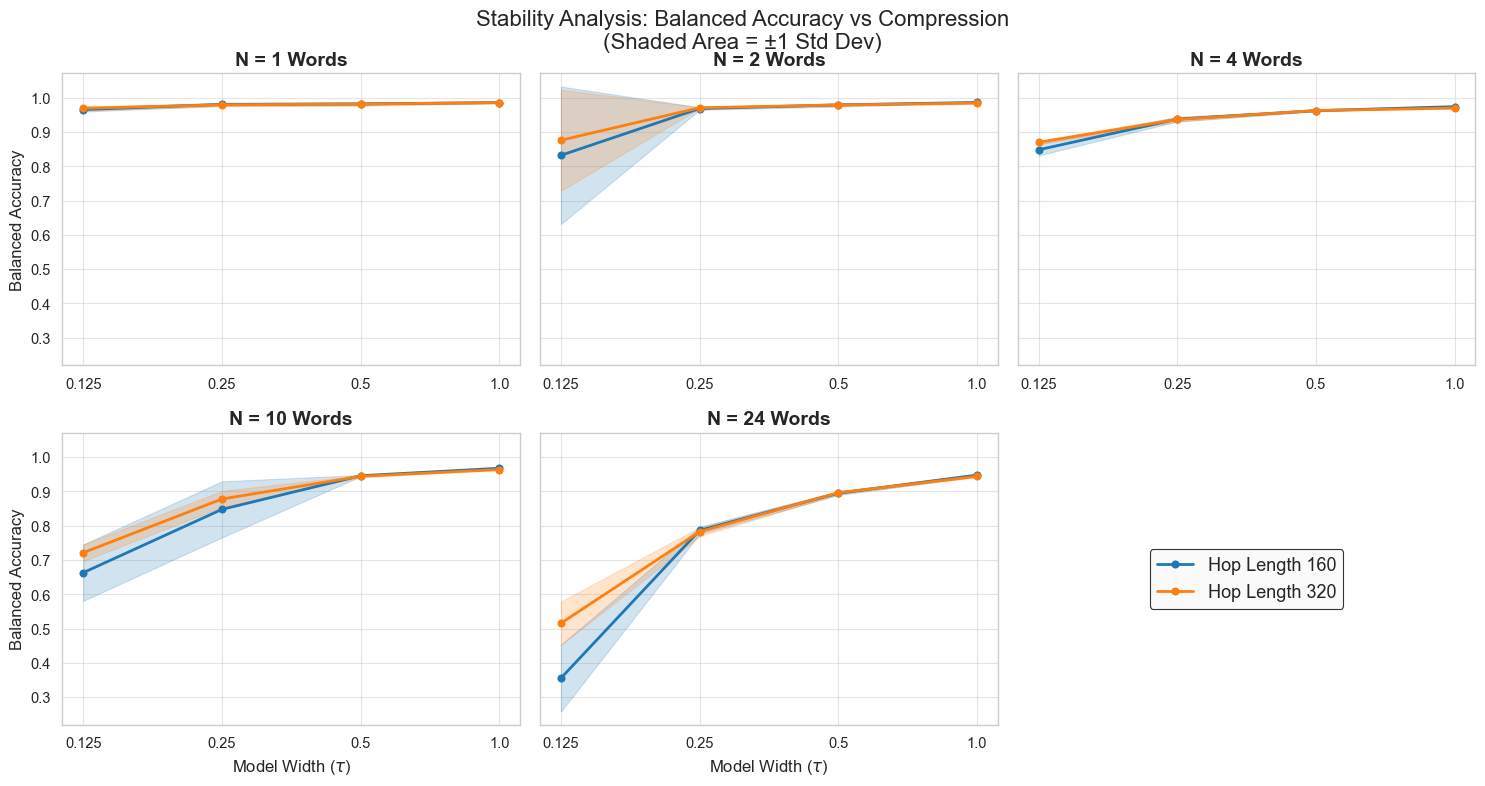

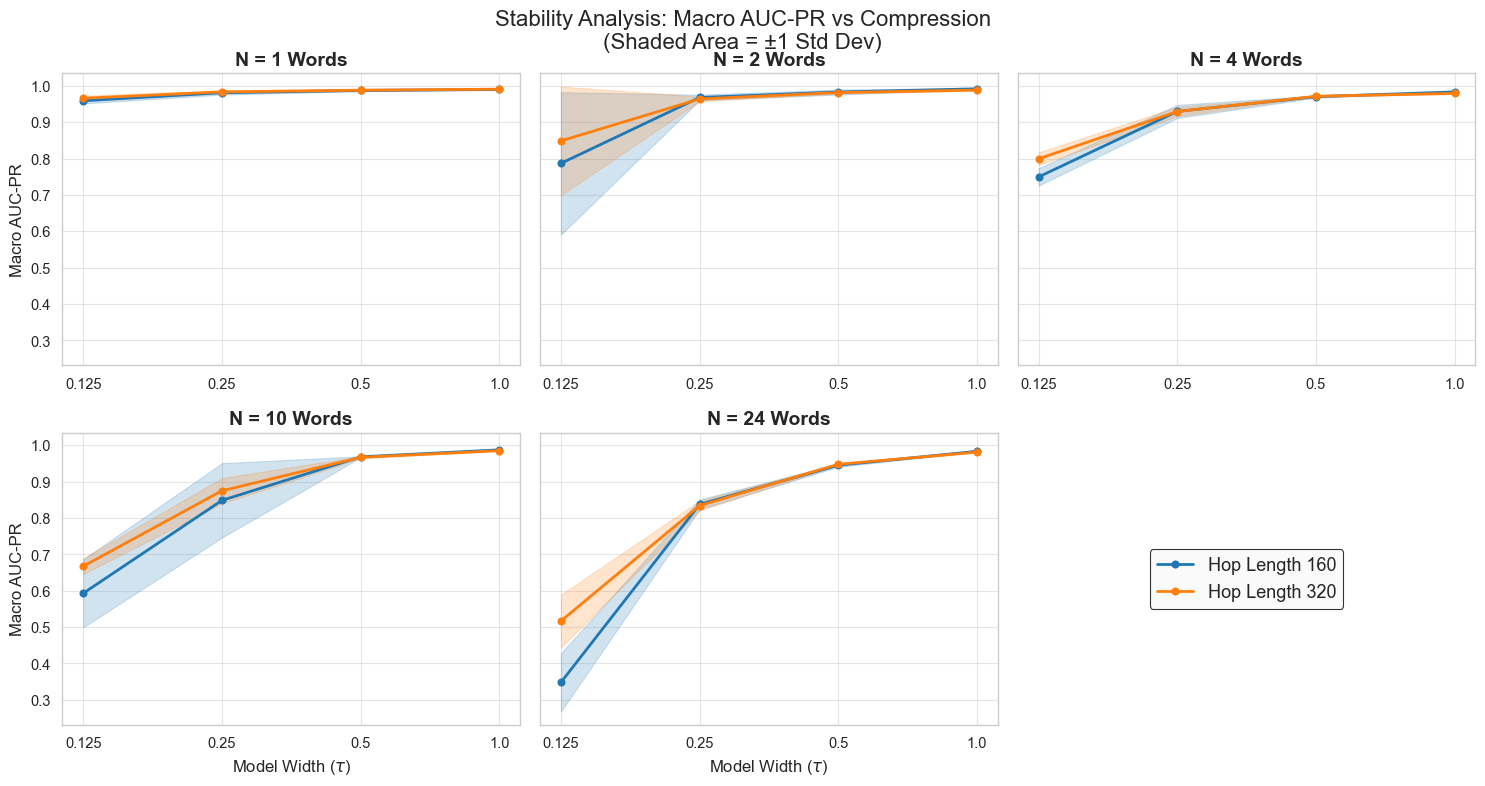

In [13]:
# Style configuration
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


def plot_stability_analysis(df, metric_mean, metric_std, title_y, filename):
    # Ensure correct ordering
    Ns = sorted(df["N"].unique())
    hop_lengths = sorted(df["HOP_LENGTH"].unique())

    # Subplot Grid (2 rows x 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
    axes_flat = axes.flatten()

    colors = sns.color_palette("tab10", n_colors=len(hop_lengths))

    # Loop through each N (Vocabulary size)
    for i, n_val in enumerate(Ns):
        ax = axes_flat[i]
        df_n = df[df["N"] == n_val]

        # Loop through Hop Length
        for j, hl in enumerate(hop_lengths):
            df_subset = df_n[df_n["HOP_LENGTH"] == hl].sort_values(by="TAU")

            x = df_subset["TAU"]
            y = df_subset[metric_mean]
            y_std = df_subset[metric_std]

            # Plot Line and Standard Deviation Shading
            ax.plot(x, y, marker="o", label=f"HL {hl}", color=colors[j], linewidth=2)
            ax.fill_between(x, y - y_std, y + y_std, color=colors[j], alpha=0.2)

        # --- X-AXIS FORMATTING ---
        ax.set_title(f"N = {n_val} Words", fontsize=14, fontweight="bold")
        ax.set_xscale("log")
        ax.set_xticks([0.125, 0.25, 0.5, 1.0])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        ax.get_xaxis().set_minor_formatter(NullFormatter())
        ax.set_xticklabels(["0.125", "0.25", "0.5", "1.0"])
        ax.grid(True, which="major", ls="-", alpha=0.5)

    # Global Labels
    for ax in axes[1, :]:  # Bottom row
        ax.set_xlabel(r"Model Width ($\tau$)", fontsize=12)
    for ax in axes[:, 0]:  # Left column
        ax.set_ylabel(title_y, fontsize=12)

    # --- LEGEND CONFIGURATION IN EMPTY SLOT ---
    if len(Ns) < len(axes_flat):
        last_ax = axes_flat[-1]
        last_ax.axis("off")

        legend_handles = []
        for j, hl in enumerate(hop_lengths):
            line = Line2D(
                [0], [0], color=colors[j], marker="o", lw=2, label=f"Hop Length {hl}"
            )
            legend_handles.append(line)

        last_ax.legend(
            handles=legend_handles,
            loc="center",
            title_fontsize=14,
            fontsize=13,
            frameon=True,
            edgecolor="black",
            facecolor="#f9f9f9",
        )
    else:
        fig.legend(
            loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=len(hop_lengths)
        )

    plt.suptitle(
        f"Stability Analysis: {title_y} vs Compression\n(Shaded Area = ±1 Std Dev)",
        fontsize=16,
        y=0.98,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# --- Execution ---
plot_stability_analysis(
    df_metrics_agg,
    metric_mean="balanced_acc_mean",
    metric_std="balanced_acc_std",
    title_y="Balanced Accuracy",
    filename=os.path.join(FIGURES_DIR, "stability_balanced_acc.png"),
)

plot_stability_analysis(
    df_metrics_agg,
    metric_mean="macro_auc_pr_mean",
    metric_std="macro_auc_pr_std",
    title_y="Macro AUC-PR",
    filename=os.path.join(FIGURES_DIR, "stability_auc_pr.png"),
)

### Deafness vs. Hallucination

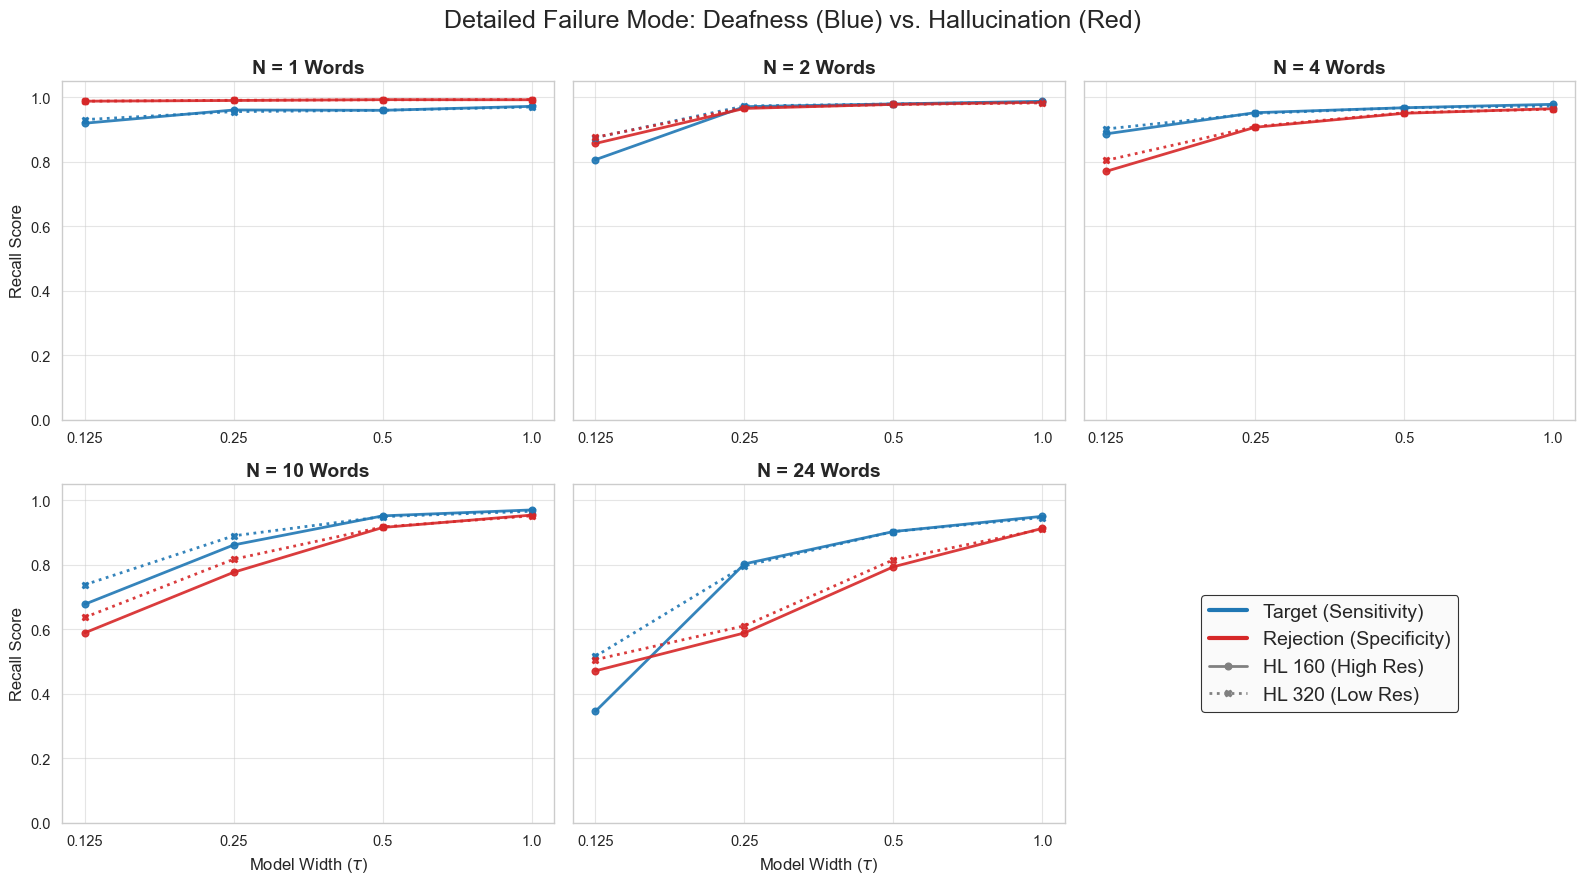

In [14]:
# Style configuration
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


def plot_deafness_vs_hallucination(df, filename):
    Ns = sorted(df["N"].unique())
    hop_lengths = sorted(df["HOP_LENGTH"].unique())

    # Dynamic 2x3 Grid
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
    axes_flat = axes.flatten()

    # Colors and Styles
    colors = {"Target": "#1f77b4", "Rejection": "#d62728"}
    linestyles = {160: "-", 320: ":"}
    markers = {160: "o", 320: "X"}

    # Legend handles
    custom_lines = [
        Line2D([0], [0], color=colors["Target"], lw=3, label="Target (Sensitivity)"),
        Line2D(
            [0], [0], color=colors["Rejection"], lw=3, label="Rejection (Specificity)"
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=2,
            linestyle="-",
            marker="o",
            label="HL 160 (High Res)",
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=2,
            linestyle=":",
            marker="X",
            label="HL 320 (Low Res)",
        ),
    ]

    # Plotting Loop
    for i, n_val in enumerate(Ns):
        ax = axes_flat[i]
        df_n = df[df["N"] == n_val]

        for hl in hop_lengths:
            df_subset = df_n[df_n["HOP_LENGTH"] == hl].sort_values("TAU")
            x = df_subset["TAU"]

            # Plot Target Recall
            ax.plot(
                x,
                df_subset["target_recall_mean"],
                marker=markers[hl],
                linestyle=linestyles[hl],
                color=colors["Target"],
                linewidth=2,
                alpha=0.9,
            )

            # Plot Rejection Recall
            ax.plot(
                x,
                df_subset["rejection_recall_mean"],
                marker=markers[hl],
                linestyle=linestyles[hl],
                color=colors["Rejection"],
                linewidth=2,
                alpha=0.9,
            )

        # Subplot Formatting
        ax.set_title(f"N = {n_val} Words", fontsize=14, fontweight="bold")
        ax.set_xscale("log")
        ax.set_xticks([0.125, 0.25, 0.5, 1.0])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        ax.get_xaxis().set_minor_formatter(NullFormatter())
        ax.set_xticklabels(["0.125", "0.25", "0.5", "1.0"])
        ax.set_ylim(0, 1.05)
        ax.grid(True, which="major", ls="-", alpha=0.5)

    # Global Axis Labels
    for ax in axes[1, :]:  # Bottom row
        ax.set_xlabel(r"Model Width ($\tau$)", fontsize=12)
    for ax in axes[:, 0]:  # Left column
        ax.set_ylabel("Recall Score", fontsize=12)

    # Legend positioning in the empty grid slot
    if len(Ns) < len(axes_flat):
        last_ax = axes_flat[-1]
        last_ax.axis("off")

        last_ax.legend(
            handles=custom_lines,
            loc="center",
            fontsize=14,
            title_fontsize=16,
            frameon=True,
            edgecolor="black",
            facecolor="#f9f9f9",
        )
    else:
        fig.legend(
            handles=custom_lines, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0.02)
        )

    plt.suptitle(
        "Detailed Failure Mode: Deafness (Blue) vs. Hallucination (Red)",
        fontsize=18,
        y=0.98,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# Execution
plot_deafness_vs_hallucination(
    df_metrics_agg, filename=os.path.join(FIGURES_DIR, "deafness_vs_hallucination.png")
)

## Hardware Requirements Estimation

### Helper Functions

In [15]:
import math


def estimate_hardware_requirements(params, macs, hop_length, tau, stride_seconds=0.5):
    """
    Estimates hardware requirements for the BC-ResNet architecture.

    Args:
        params (int): Number of model parameters.
        macs (int): Number of Multiply-Accumulate operations.
        hop_length (int): Hop Length used (160 or 320).
        tau (float): Width multiplier (0.125 to 1.0).
        stride_seconds (float): Interval between inferences (default 0.5s).

    Returns:
        dict: {
            'flash_kb': float,    # Required Flash memory in KB
            'ram_kb': float,      # Required RAM (Peak) in KB
            'clock_mhz': float,   # Minimum required CPU clock in MHz
            'latency_ms': float   # Estimated latency in ms (at minimum clock)
        }
    """
    # --- System Constants (Literature-based estimates) ---
    BYTES_PER_FLOAT = 4
    SYSTEM_FLASH_KB = 64.0  # RTOS + TFLite Micro overhead
    SYSTEM_RAM_KB = 10.0  # Stack + Heap + Globals overhead

    CYCLES_PER_MAC = 12.0  # Unoptimized
    PREPROC_FACTOR = 1.25  # +25% overhead for FFT/MFCC
    CPU_UTILIZATION = 1.0  # 100% utilization allowed within the window

    SR = 16000
    DURATION = 1.0  # Model input window (seconds)
    N_MELS = 40

    # FLASH (Memory footprint)
    model_size_kb = (params * BYTES_PER_FLOAT) / 1024
    req_flash = SYSTEM_FLASH_KB + model_size_kb

    # RAM (Peak usage estimation)
    # Time dimension T
    t_dim = math.ceil((SR * DURATION) / hop_length)

    # Input Buffer (40 x T Spectrogram)
    input_buffer_elems = N_MELS * t_dim
    input_buffer_kb = (input_buffer_elems * BYTES_PER_FLOAT) / 1024

    # Tensor Arena (Heuristic for BC-ResNet internal feature maps)
    # Effective width (channels) based on Tau (C_base ~ 8)
    c_eff = max(1, int(8 * tau))

    # Peak memory usually occurs during the first convolution or within residual blocks.
    # Conservatively estimated as 2x the internal feature map size (Ping-Pong buffer).
    feature_map_elems = c_eff * N_MELS * t_dim
    tensor_arena_kb = (feature_map_elems * 2 * BYTES_PER_FLOAT) / 1024

    # Peak usage assumes input buffer and the largest activation maps
    peak_ram_usage = max(input_buffer_kb, tensor_arena_kb)
    req_ram = SYSTEM_RAM_KB + input_buffer_kb + peak_ram_usage

    # CLOCK (Processing power)
    # Total cycles required per inference
    total_cycles = macs * CYCLES_PER_MAC * PREPROC_FACTOR

    # Required frequency to process within the stride (Hz)
    req_clock_hz = total_cycles / (stride_seconds * CPU_UTILIZATION)
    req_clock_mhz = req_clock_hz / 1e6

    return {
        "flash_kb": round(req_flash, 1),
        "ram_kb": round(req_ram, 1),
        "clock_mhz": round(req_clock_mhz, 1),
        "latency_ms": round((total_cycles / req_clock_hz) * 1000, 1),
    }

In [16]:
def suggest_models_for_mcu(flash_kb, ram_kb, clock_mhz, df_hardware):
    suitable_models = []

    for idx, row in df_hardware.iterrows():
        if (
            row["flash_kb"] <= flash_kb
            and row["ram_kb"] <= ram_kb
            and row["clock_mhz"] <= clock_mhz
        ):
            suitable_models.append(row)

    return pd.DataFrame(suitable_models)

### Estimating Hardware Requirements

In [17]:
df_hardware = df_metrics_agg.apply(
    lambda row: estimate_hardware_requirements(
        row["Params"], row["MACs"], row["HOP_LENGTH"], row["TAU"], stride_seconds=0.5
    ),
    axis=1,
).apply(pd.Series)

# Add the grouping columns
df_hardware = pd.concat(
    [
        df_metrics_agg[["N", "TAU", "HOP_LENGTH"]],
        df_hardware[["flash_kb", "ram_kb", "clock_mhz"]],
    ],
    axis=1,
)
df_hardware.sort_values(
    by=["N", "TAU", "HOP_LENGTH"], ascending=[True, True, False], inplace=True
)

df_hardware.to_csv(os.path.join(TABLES_DIR, "hardware_requirements.csv"), index=False)
df_hardware

,N,TAU,HOP_LENGTH,flash_kb,ram_kb,clock_mhz
1,1,0.125,320,66.1,33.4,2.5
0,1,0.125,160,66.1,56.9,5.0
3,1,0.250,320,69.5,49.1,6.1
2,1,0.250,160,69.5,88.1,12.0
5,1,0.500,320,77.1,80.3,14.4
4,1,0.500,160,77.1,150.6,28.4
7,1,1.000,320,98.9,142.8,37.7
6,1,1.000,160,98.9,275.6,74.5
9,2,0.125,320,66.1,33.4,2.5
8,2,0.125,160,66.1,56.9,5.0


In [18]:
df_hardware_24 = (
    df_hardware[df_hardware["N"] == 24]
    .sort_values(by=["TAU", "HOP_LENGTH"], ascending=[True, False])
    .drop(columns=["N"])
)
df_hardware_24

,TAU,HOP_LENGTH,flash_kb,ram_kb,clock_mhz
33,0.125,320,66.6,33.4,2.5
32,0.125,160,66.6,56.9,5.0
35,0.250,320,70.3,49.1,6.1
34,0.250,160,70.3,88.1,12.0
37,0.500,320,78.7,80.3,14.4
36,0.500,160,78.7,150.6,28.4
39,1.000,320,101.9,142.8,37.7
38,1.000,160,101.9,275.6,74.6


### Defining Models by MCU

In [19]:
mcus = [
    {"nome": "STM32F103 (Blue Pill)", "clock": 72, "flash": 64, "ram": 20},
    {"nome": "STM32F401 (Black Pill)", "clock": 84, "flash": 256, "ram": 64},
    {"nome": "nRF52840 (Nano 33 BLE)", "clock": 64, "flash": 1024, "ram": 256},
    {"nome": "ESP32", "clock": 240, "flash": 4096, "ram": 520},
]

mcu_comparative_data = []

for mcu in mcus:
    compatible_models = suggest_models_for_mcu(
        flash_kb=mcu["flash"],
        ram_kb=mcu["ram"],
        clock_mhz=mcu["clock"],
        df_hardware=df_hardware,
    )

    if compatible_models.empty:
        line = mcu | {"N_1": None, "N_2": None, "N_4": None, "N_10": None, "N_24": None}
        mcu_comparative_data.append(line)
        continue

    N_1_models = compatible_models[compatible_models["N"] == 1].sort_values(
        by=["TAU", "HOP_LENGTH"], ascending=[False, True]
    )
    N_2_models = compatible_models[compatible_models["N"] == 2].sort_values(
        by=["TAU", "HOP_LENGTH"], ascending=[False, True]
    )
    N_4_models = compatible_models[compatible_models["N"] == 4].sort_values(
        by=["TAU", "HOP_LENGTH"], ascending=[False, True]
    )
    N_10_models = compatible_models[compatible_models["N"] == 10].sort_values(
        by=["TAU", "HOP_LENGTH"], ascending=[False, True]
    )
    N_24_models = compatible_models[compatible_models["N"] == 24].sort_values(
        by=["TAU", "HOP_LENGTH"], ascending=[False, True]
    )

    N_1_best = (
        (N_1_models.iloc[0]["TAU"], N_1_models.iloc[0]["HOP_LENGTH"])
        if not N_1_models.empty
        else None
    )
    N_2_best = (
        (N_2_models.iloc[0]["TAU"], N_2_models.iloc[0]["HOP_LENGTH"])
        if not N_2_models.empty
        else None
    )
    N_4_best = (
        (N_4_models.iloc[0]["TAU"], N_4_models.iloc[0]["HOP_LENGTH"])
        if not N_4_models.empty
        else None
    )
    N_10_best = (
        (N_10_models.iloc[0]["TAU"], N_10_models.iloc[0]["HOP_LENGTH"])
        if not N_10_models.empty
        else None
    )
    N_24_best = (
        (N_24_models.iloc[0]["TAU"], N_24_models.iloc[0]["HOP_LENGTH"])
        if not N_24_models.empty
        else None
    )

    line = mcu | {
        "N_1": N_1_best,
        "N_2": N_2_best,
        "N_4": N_4_best,
        "N_10": N_10_best,
        "N_24": N_24_best,
    }

    mcu_comparative_data.append(line)

df_mcu_comparative = pd.DataFrame(mcu_comparative_data)
df_mcu_comparative

,nome,clock,flash,ram,N_1,N_2,N_4,N_10,N_24
0,STM32F103 (Blue Pill),72,64,20,None,None,None,None,None
1,STM32F401 (Black Pill),84,256,64,"(0.25, 320.0)","(0.25, 320.0)","(0.25, 320.0)","(0.25, 320.0)","(0.25, 320.0)"
2,nRF52840 (Nano 33 BLE),64,1024,256,"(1.0, 320.0)","(1.0, 320.0)","(1.0, 320.0)","(1.0, 320.0)","(1.0, 320.0)"
3,ESP32,240,4096,520,"(1.0, 160.0)","(1.0, 160.0)","(1.0, 160.0)","(1.0, 160.0)","(1.0, 160.0)"


## LaTeX Helper

In [20]:
current_n = None
current_tau = None
indent = " " * 8

# Sort and iterate to generate LaTeX table rows
# Ordering by N (ascending), TAU (descending), and HOP_LENGTH (ascending)
for idx, row in df_metrics_agg.sort_values(
    by=["N", "TAU", "HOP_LENGTH"], ascending=[True, False, True]
).iterrows():

    # Value formatting
    n_val = int(row["N"])
    tau_val = row["TAU"]
    hop_val = int(row["HOP_LENGTH"])

    params_str = "\\multirow{2}{*}{%s}" % f"{int(row['Params']):,}"

    # MACs unit formatting
    if row["MACs"] <= 1e3:
        macs_str = f"{row['MACs']}"
    elif row["MACs"] <= 1e6:
        macs_str = f"{int(row['MACs']/1e3)}k"
    elif row["MACs"] <= 1e9:
        macs_str = f"{row['MACs']/1e6:.2f}M"

    # Logical handling for multi-row cells (TAU and Params)
    if current_tau != tau_val:
        tau_str = "\\multirow{2}{*}{%s}" % str(tau_val)
        current_tau = tau_val
        sep_tau = indent + "\\cmidrule{2-9}\n"
    else:
        tau_str = "  "
        params_str = "  "
        sep_tau = ""

    # Visual separator for different Vocabulary Sizes (N)
    if current_n != row["N"]:
        sep_tau = ""
        print(indent + "\\midrule\n")
        print(indent + f"% --- N = {int(row['N'])} ---")
        print(indent + "\\multirow{8}{*}{%d}" % int(row["N"]))
        current_n = row["N"]

    # Format Metrics as Percentage: Mean ± Std Dev
    bal_acc = (
        f"{row['balanced_acc_mean']*100:.1f} $\\pm$ {row['balanced_acc_std']*100:.1f}"
    )
    auc_pr_acc = (
        f"{row['macro_auc_pr_mean']*100:.1f} $\\pm$ {row['macro_auc_pr_std']*100:.1f}"
    )
    tgt_rec = (
        f"{row['target_recall_mean']*100:.1f} $\\pm$ {row['target_recall_std']*100:.1f}"
    )
    rej_rec = f"{row['rejection_recall_mean']*100:.1f} $\\pm$ {row['rejection_recall_std']*100:.1f}"

    # Generate the LaTeX row
    line = f"{sep_tau}{indent}  & {tau_str} & {hop_val} & {params_str} & {macs_str} & {bal_acc} & {auc_pr_acc} & {tgt_rec} & {rej_rec} \\\\"

    print(line)

        \midrule

        % --- N = 1 ---
        \multirow{8}{*}{1}
          & \multirow{2}{*}{1.0} & 160 & \multirow{2}{*}{8,935} & 2.48M & 98.6 $\pm$ 0.1 & 99.0 $\pm$ 0.2 & 97.2 $\pm$ 0.6 & 99.3 $\pm$ 0.2 \\
          &    & 320 &    & 1.26M & 98.6 $\pm$ 0.2 & 99.1 $\pm$ 0.2 & 97.0 $\pm$ 0.7 & 99.3 $\pm$ 0.3 \\
        \cmidrule{2-9}
          & \multirow{2}{*}{0.5} & 160 & \multirow{2}{*}{3,365} & 947k & 98.2 $\pm$ 0.3 & 98.7 $\pm$ 0.2 & 96.0 $\pm$ 1.0 & 99.3 $\pm$ 0.1 \\
          &    & 320 &    & 478k & 98.2 $\pm$ 0.6 & 98.8 $\pm$ 0.3 & 96.0 $\pm$ 1.7 & 99.3 $\pm$ 0.1 \\
        \cmidrule{2-9}
          & \multirow{2}{*}{0.25} & 160 & \multirow{2}{*}{1,408} & 399k & 98.1 $\pm$ 0.4 & 98.1 $\pm$ 0.5 & 96.1 $\pm$ 1.1 & 99.0 $\pm$ 0.2 \\
          &    & 320 &    & 202k & 97.9 $\pm$ 0.4 & 98.3 $\pm$ 0.4 & 95.6 $\pm$ 1.2 & 99.1 $\pm$ 0.1 \\
        \cmidrule{2-9}
          & \multirow{2}{*}{0.125} & 160 & \multirow{2}{*}{544} & 167k & 96.6 $\pm$ 0.6 & 95.9 $\pm$ 0.7 & 92.0 $\pm$ 1.9

In [21]:
current_tau = None
indent = " " * 8

for idx, row in df_hardware_24.iterrows():
    tau_val = row["TAU"]
    hop_val = int(row["HOP_LENGTH"])
    flash_kb = math.ceil(row["flash_kb"])
    ram_kb = math.ceil(row["ram_kb"])
    clock_mhz = math.ceil(row["clock_mhz"])

    if current_tau != tau_val:
        sep_tau = indent + "\\midrule\n\n"
        current_tau = tau_val
        tau_str = "\\multirow{2}{*}{%s}" % str(tau_val)
    else:
        tau_str = "  "
        sep_tau = ""

    line = f"{sep_tau}{indent} {tau_str} & {hop_val} & {flash_kb} & {ram_kb} & {clock_mhz} \\\\"

    print(line)

        \midrule

         \multirow{2}{*}{0.125} & 320 & 67 & 34 & 3 \\
            & 160 & 67 & 57 & 5 \\
        \midrule

         \multirow{2}{*}{0.25} & 320 & 71 & 50 & 7 \\
            & 160 & 71 & 89 & 12 \\
        \midrule

         \multirow{2}{*}{0.5} & 320 & 79 & 81 & 15 \\
            & 160 & 79 & 151 & 29 \\
        \midrule

         \multirow{2}{*}{1.0} & 320 & 102 & 143 & 38 \\
            & 160 & 102 & 276 & 75 \\


## End